In [ ]:
'''Here is an revised version of FGM based on 180805 Files. Main differences:

1. Instead of generating the fixed mutation effect in advance before evolution, here we generated the mutation effect of each 
mutation only when the mutation occurs.
2. Instead of not allowing back mutations, here we made the infinite allele assumption, i.e., a mutated allele can also be 
mutated to another mutated allele.

Here similar to 180805 files, we assumed no pleyotropy (or "very restricted pleyotropy"), that each locus only corresponds to 1 
dimension within the landscape.

Here we compared the evolution of Tetrahymena (P =45) with population size N =100 under different reproduction strategies. Here
three values of STD to generate the mutation were tested: 0.01, 0.05 and 0.1. Initial fitness is set to be 1 and 100 replicates 
for each settings.

'''

In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [3]:
def get_data(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.Fit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.Fit_STD,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.Var_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.Var_STD,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180903_Test of Fisher's Geometric Model_Infinite Allele Assumption\Data\N100\Sigma =0.01")

In [5]:
file_sg01 = ['FGM_Mito_N100_SM001_F1_100Rep.csv', 'FGM_Amito_N100_SM001_F1_100Rep.csv', 'FGM_RM_N100_SM001_F1_100Rep.csv', \
       'FGM_RM_E100_N100_SM001_F1_100Rep.csv', 'FGM_SF_N100_SM001_F1_100Rep.csv', 'FGM_SF_E100_N100_SM001_F1_100Rep.csv']

In [6]:
m = get_data(file_sg01)

sg01_fit_mean =m[0]
sg01_fit_std = m[1]
sg01_var_mean =m[2]
sg01_var_std = m[3]

In [7]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180903_Test of Fisher's Geometric Model_Infinite Allele Assumption\Data\N100\Sigma =0.05")

In [8]:
file_sg05 = ['FGM_Mito_N100_SM005_F1_100Rep.csv', 'FGM_Amito_N100_SM005_F1_100Rep.csv', 'FGM_RM_N100_SM005_F1_100Rep.csv', \
       'FGM_RM_E100_N100_SM005_F1_100Rep.csv', 'FGM_SF_N100_SM005_F1_100Rep.csv', 'FGM_SF_E100_N100_SM005_F1_100Rep.csv']

In [9]:
s = get_data(file_sg05)

sg05_fit_mean =s[0]
sg05_fit_std = s[1]
sg05_var_mean =s[2]
sg05_var_std = s[3]



In [10]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180903_Test of Fisher's Geometric Model_Infinite Allele Assumption\Data\N100\Sigma =0.1")

In [11]:
file_sg1 = ['FGM_Mito_N100_SM01_F1_100Rep.csv', 'FGM_Amito_N100_SM01_F1_100Rep.csv', 'FGM_RM_N100_SM01_F1_100Rep.csv', \
       'FGM_RM_E100_N100_SM01_F1_100Rep.csv', 'FGM_SF_N100_SM01_F1_100Rep.csv', 'FGM_SF_E100_N100_SM01_F1_100Rep.csv']

In [12]:
t = get_data(file_sg1)

sg1_fit_mean =t[0]
sg1_fit_std = t[1]
sg1_var_mean =t[2]
sg1_var_std = t[3]

In [13]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

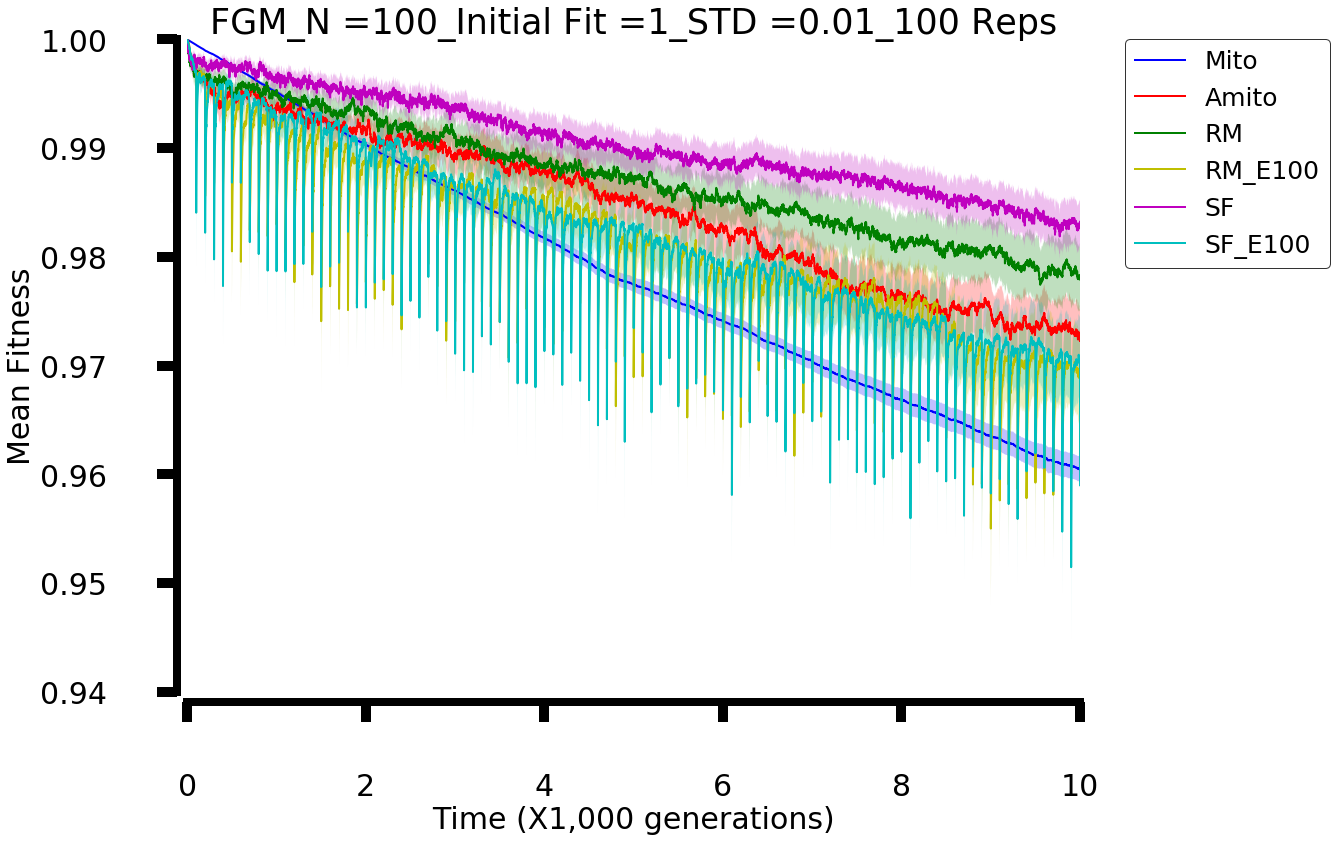

In [16]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[0]
error_a = list(1.96* np.array(sg01_fit_std[0])/((100)**0.5))

b = sg01_fit_mean[1]
error_b = list(1.96* np.array(sg01_fit_std[1])/((100)**0.5))

c = sg01_fit_mean[2]
error_c = list(1.96* np.array(sg01_fit_std[2])/((100)**0.5))

d = sg01_fit_mean[3]
error_d = list(1.96* np.array(sg01_fit_std[3])/((100)**0.5))

e = sg01_fit_mean[4]
error_e = list(1.96* np.array(sg01_fit_std[4])/((100)**0.5))

f = sg01_fit_mean[5]
error_f = list(1.96* np.array(sg01_fit_std[5])/((100)**0.5))



ax.set_title('FGM_N =100_Initial Fit =1_STD =0.01_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'Amito', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'RM', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')

ax.plot(t,d,'y', label = 'RM_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.25, facecolor='y')

ax.plot(t,e,'m', label = 'SF', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.25, facecolor='m')

ax.plot(t,f,'c', label = 'SF_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.25, facecolor='c')




ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')



ax.set_ylim(0.94, 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

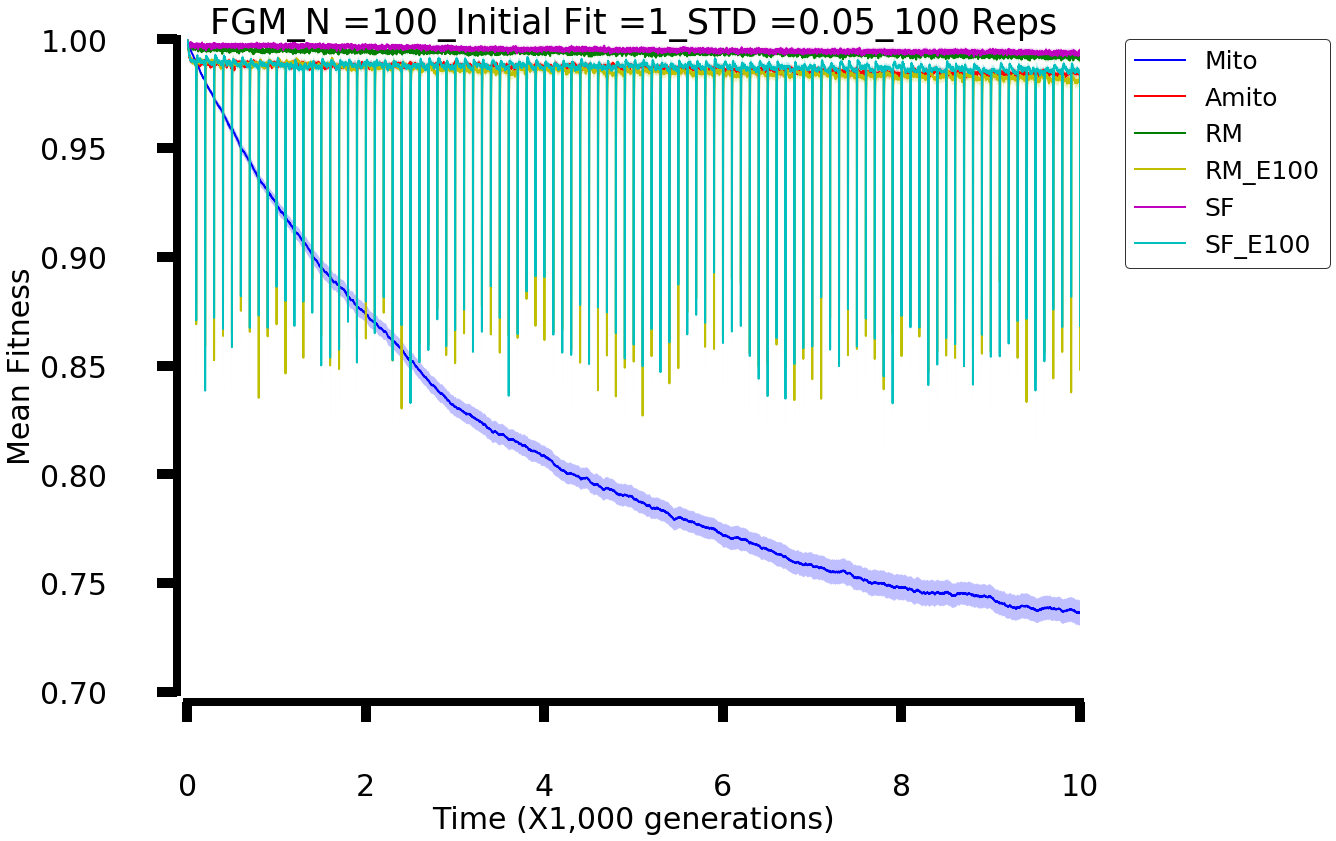

In [18]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg05_fit_mean[0]
error_a = list(1.96* np.array(sg05_fit_std[0])/((100)**0.5))

b = sg05_fit_mean[1]
error_b = list(1.96* np.array(sg05_fit_std[1])/((100)**0.5))

c = sg05_fit_mean[2]
error_c = list(1.96* np.array(sg05_fit_std[2])/((100)**0.5))

d = sg05_fit_mean[3]
error_d = list(1.96* np.array(sg05_fit_std[3])/((100)**0.5))

e = sg05_fit_mean[4]
error_e = list(1.96* np.array(sg05_fit_std[4])/((100)**0.5))

f = sg05_fit_mean[5]
error_f = list(1.96* np.array(sg05_fit_std[5])/((100)**0.5))



ax.set_title('FGM_N =100_Initial Fit =1_STD =0.05_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'Amito', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'RM', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')

ax.plot(t,d,'y', label = 'RM_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.25, facecolor='y')

ax.plot(t,e,'m', label = 'SF', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.25, facecolor='m')

ax.plot(t,f,'c', label = 'SF_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.25, facecolor='c')




ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')


ax.set_ylim(7.0*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

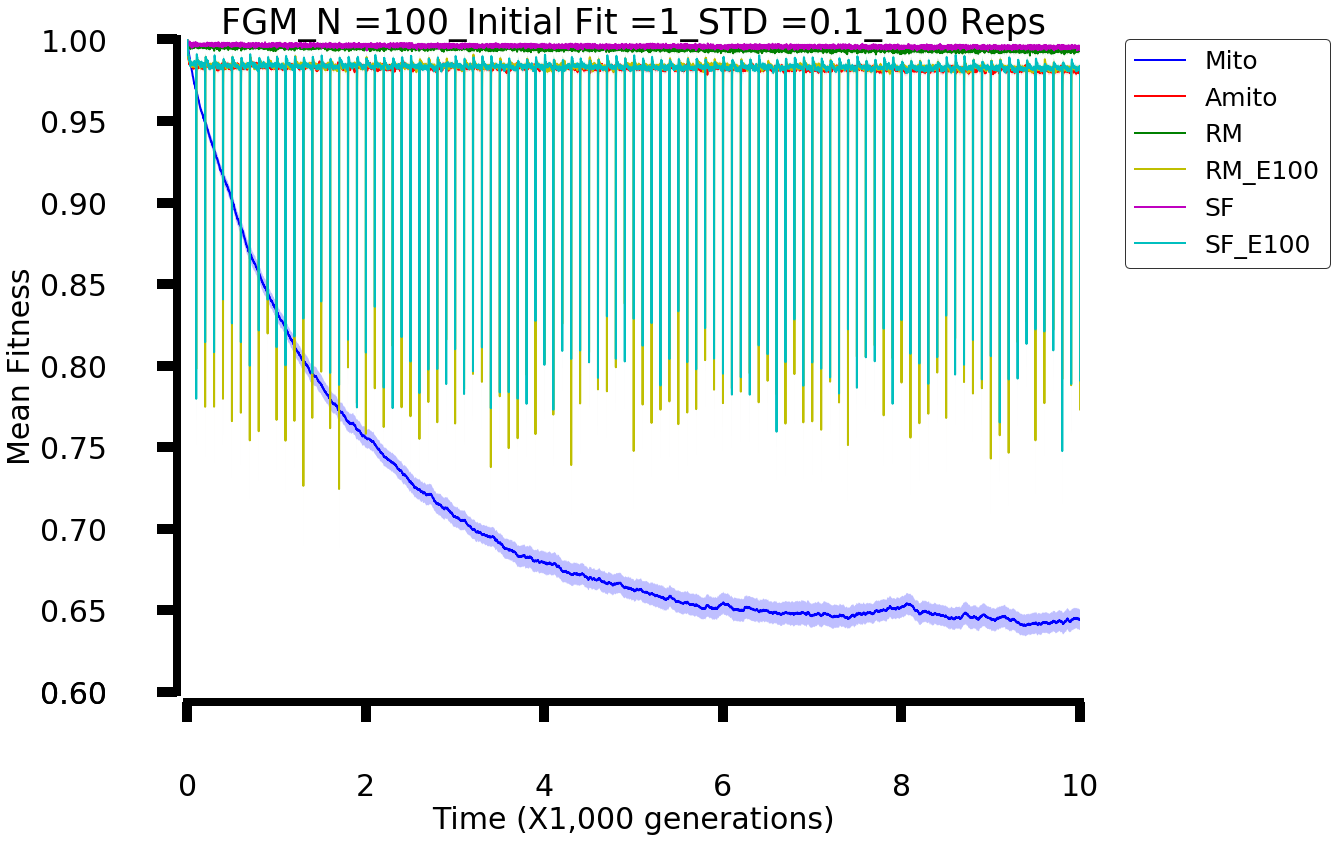

In [20]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg1_fit_mean[0]
error_a = list(1.96* np.array(sg1_fit_std[0])/((100)**0.5))

b = sg1_fit_mean[1]
error_b = list(1.96* np.array(sg1_fit_std[1])/((100)**0.5))

c = sg1_fit_mean[2]
error_c = list(1.96* np.array(sg1_fit_std[2])/((100)**0.5))

d = sg1_fit_mean[3]
error_d = list(1.96* np.array(sg1_fit_std[3])/((100)**0.5))

e = sg1_fit_mean[4]
error_e = list(1.96* np.array(sg1_fit_std[4])/((100)**0.5))

f = sg1_fit_mean[5]
error_f = list(1.96* np.array(sg1_fit_std[5])/((100)**0.5))



ax.set_title('FGM_N =100_Initial Fit =1_STD =0.1_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'Amito', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'RM', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')

ax.plot(t,d,'y', label = 'RM_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.25, facecolor='y')

ax.plot(t,e,'m', label = 'SF', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.25, facecolor='m')

ax.plot(t,f,'c', label = 'SF_E100', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.25, facecolor='c')




ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

extraticks=[0.6]
ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(6.0*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

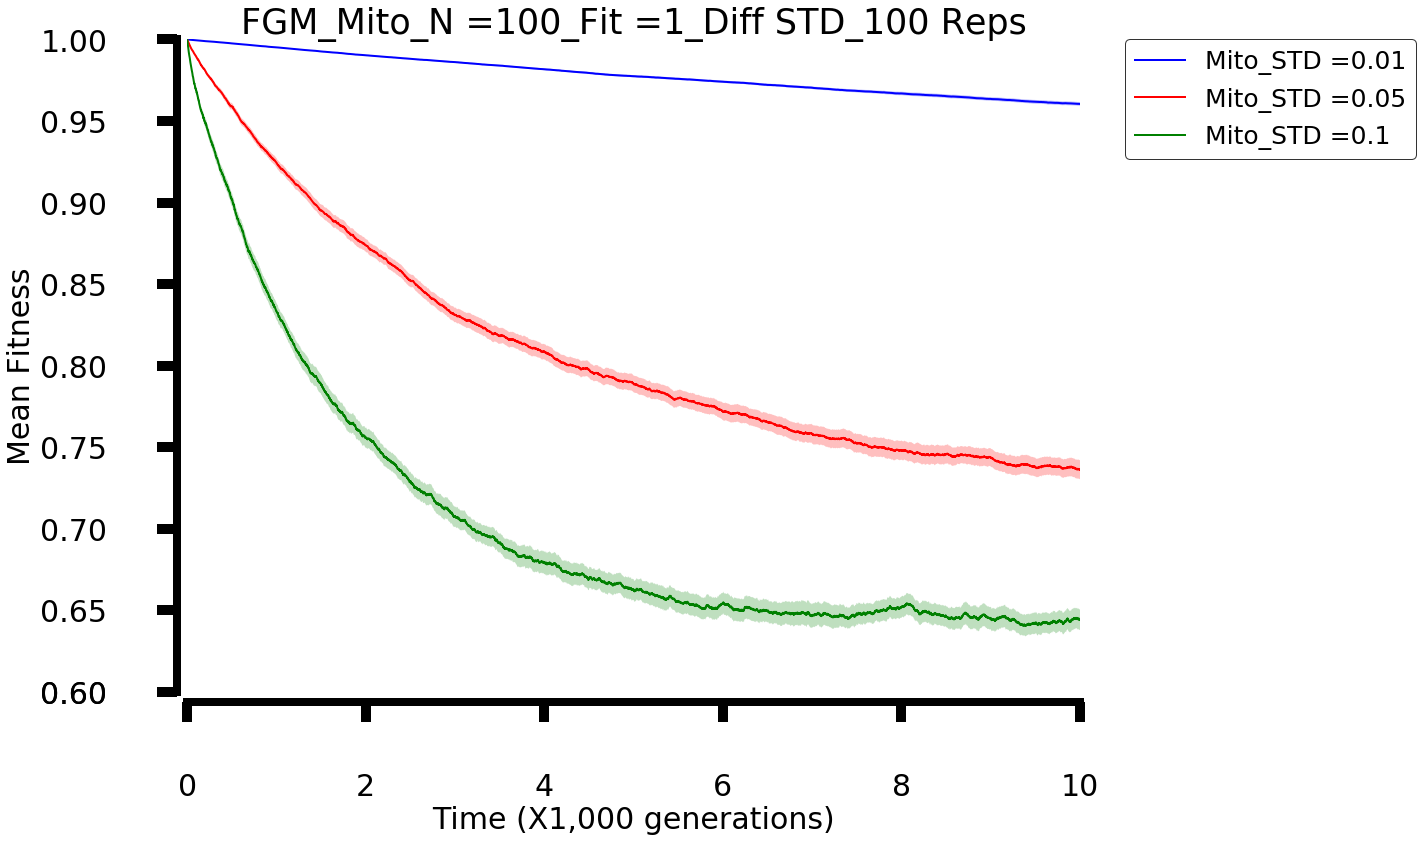

In [22]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[0]
error_a = list(1.96* np.array(sg01_fit_std[0])/((100)**0.5))

b = sg05_fit_mean[0]
error_b = list(1.96* np.array(sg05_fit_std[0])/((100)**0.5))

c = sg1_fit_mean[0]
error_c = list(1.96* np.array(sg1_fit_std[0])/((100)**0.5))


ax.set_title('FGM_Mito_N =100_Fit =1_Diff STD_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'Mito_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'Mito_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'Mito_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

extraticks=[0.6]
ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(6.0*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

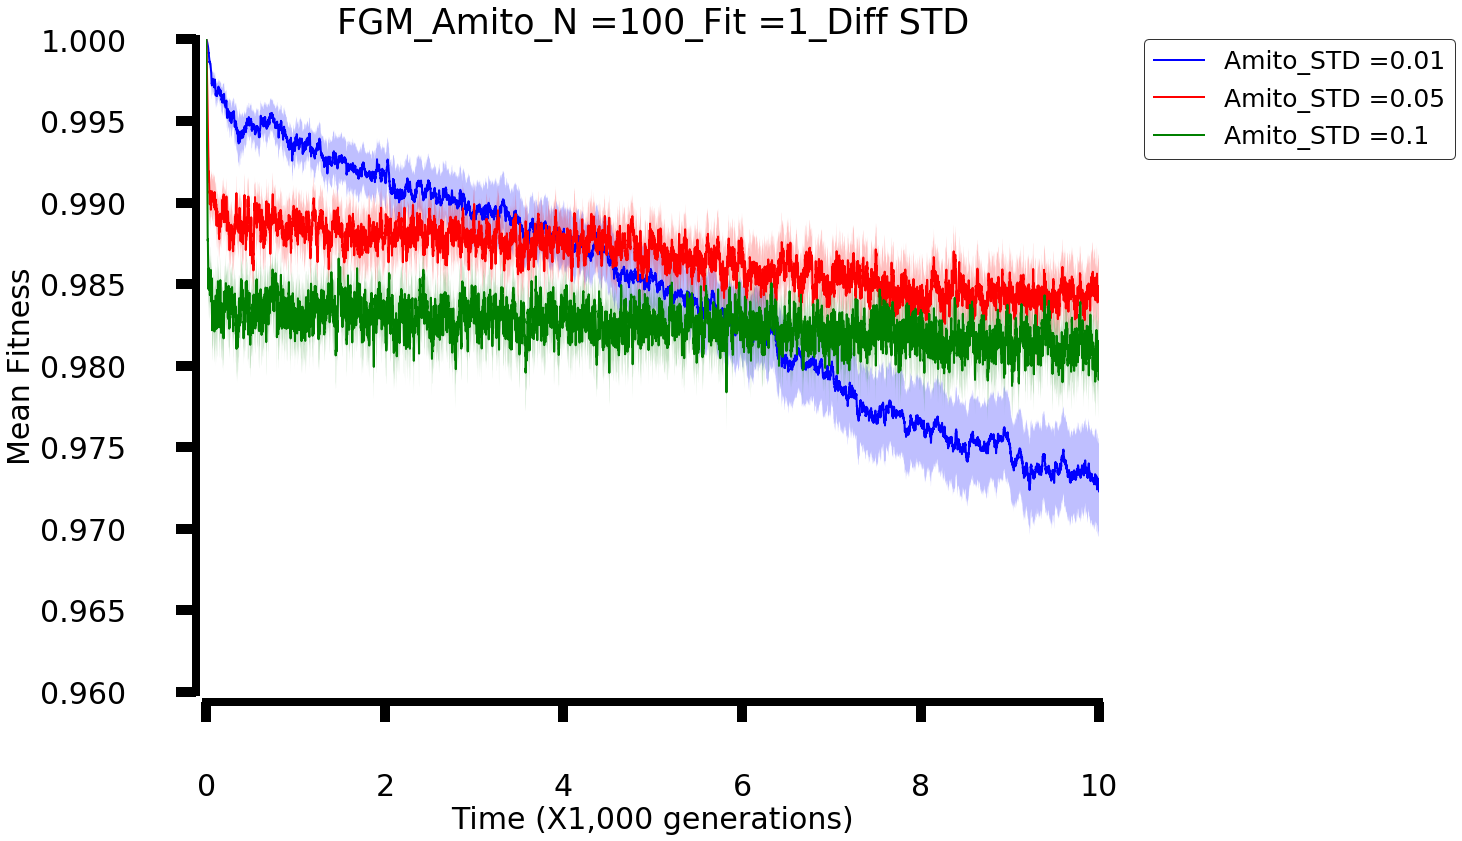

In [24]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[1]
error_a = list(1.96* np.array(sg01_fit_std[1])/((100)**0.5))

b = sg05_fit_mean[1]
error_b = list(1.96* np.array(sg05_fit_std[1])/((100)**0.5))

c = sg1_fit_mean[1]
error_c = list(1.96* np.array(sg1_fit_std[1])/((100)**0.5))


ax.set_title('FGM_Amito_N =100_Fit =1_Diff STD', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'Amito_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'Amito_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'Amito_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.6]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(9.6*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

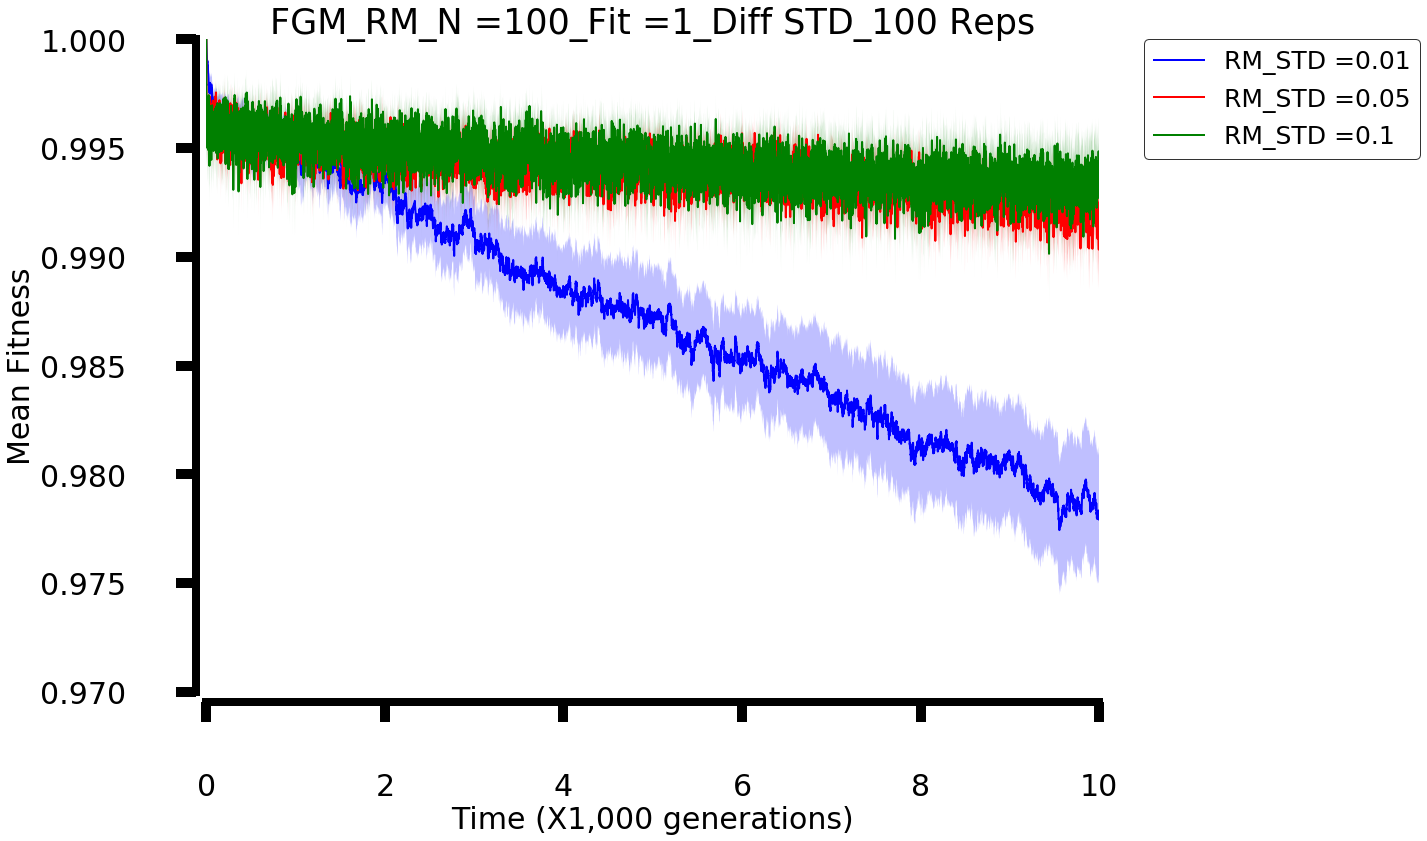

In [26]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[2]
error_a = list(1.96* np.array(sg01_fit_std[2])/((100)**0.5))

b = sg05_fit_mean[2]
error_b = list(1.96* np.array(sg05_fit_std[2])/((100)**0.5))

c = sg1_fit_mean[2]
error_c = list(1.96* np.array(sg1_fit_std[2])/((100)**0.5))


ax.set_title('FGM_RM_N =100_Fit =1_Diff STD_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'RM_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'RM_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'RM_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')



ax.set_ylim(9.7*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

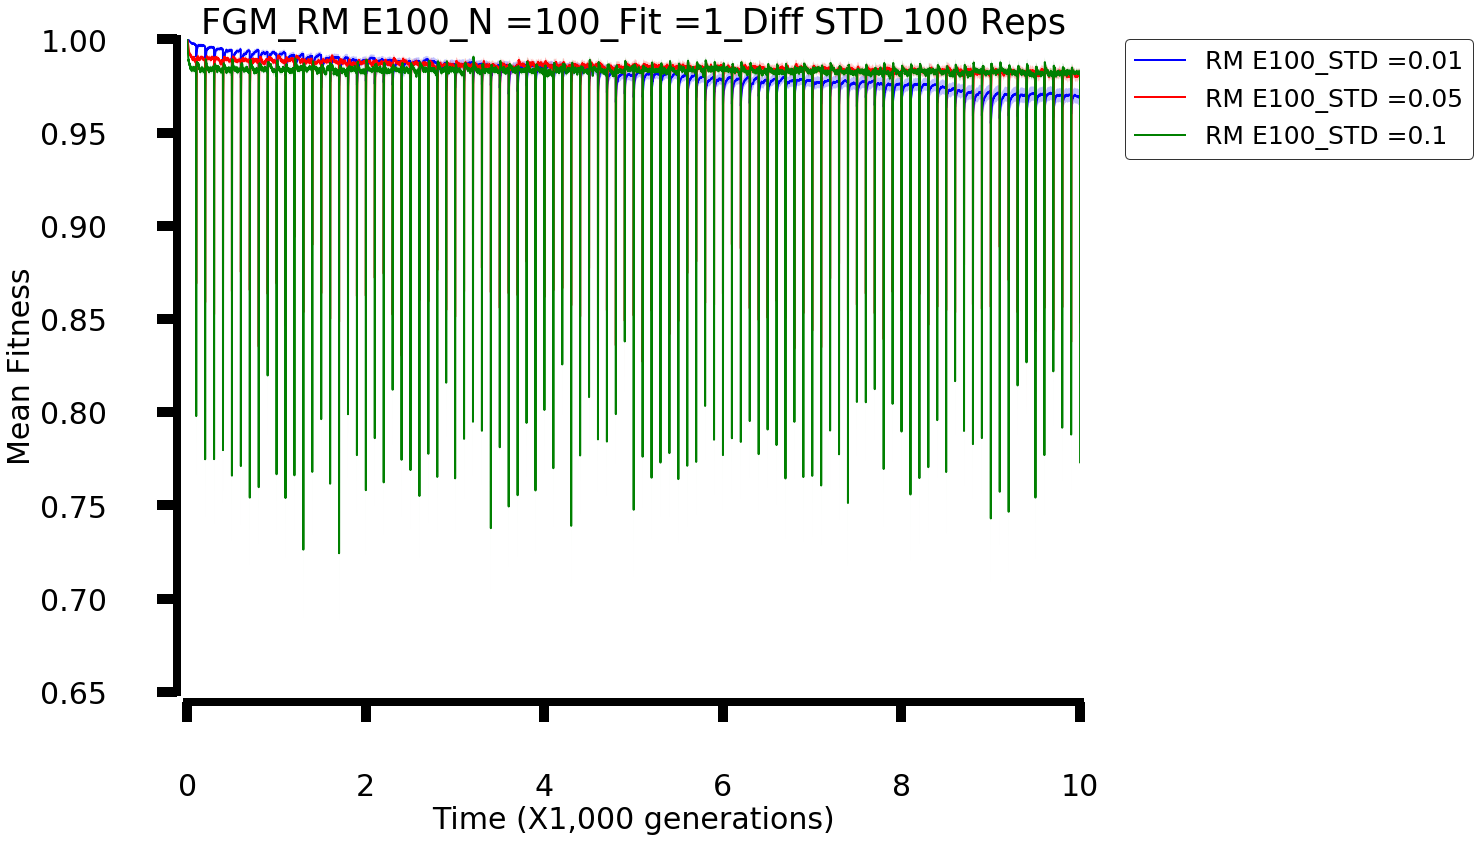

In [27]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[3]
error_a = list(1.96* np.array(sg01_fit_std[3])/((100)**0.5))

b = sg05_fit_mean[3]
error_b = list(1.96* np.array(sg05_fit_std[3])/((100)**0.5))

c = sg1_fit_mean[3]
error_c = list(1.96* np.array(sg1_fit_std[3])/((100)**0.5))


ax.set_title('FGM_RM E100_N =100_Fit =1_Diff STD_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'RM E100_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'RM E100_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'RM E100_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')



ax.set_ylim(6.5*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

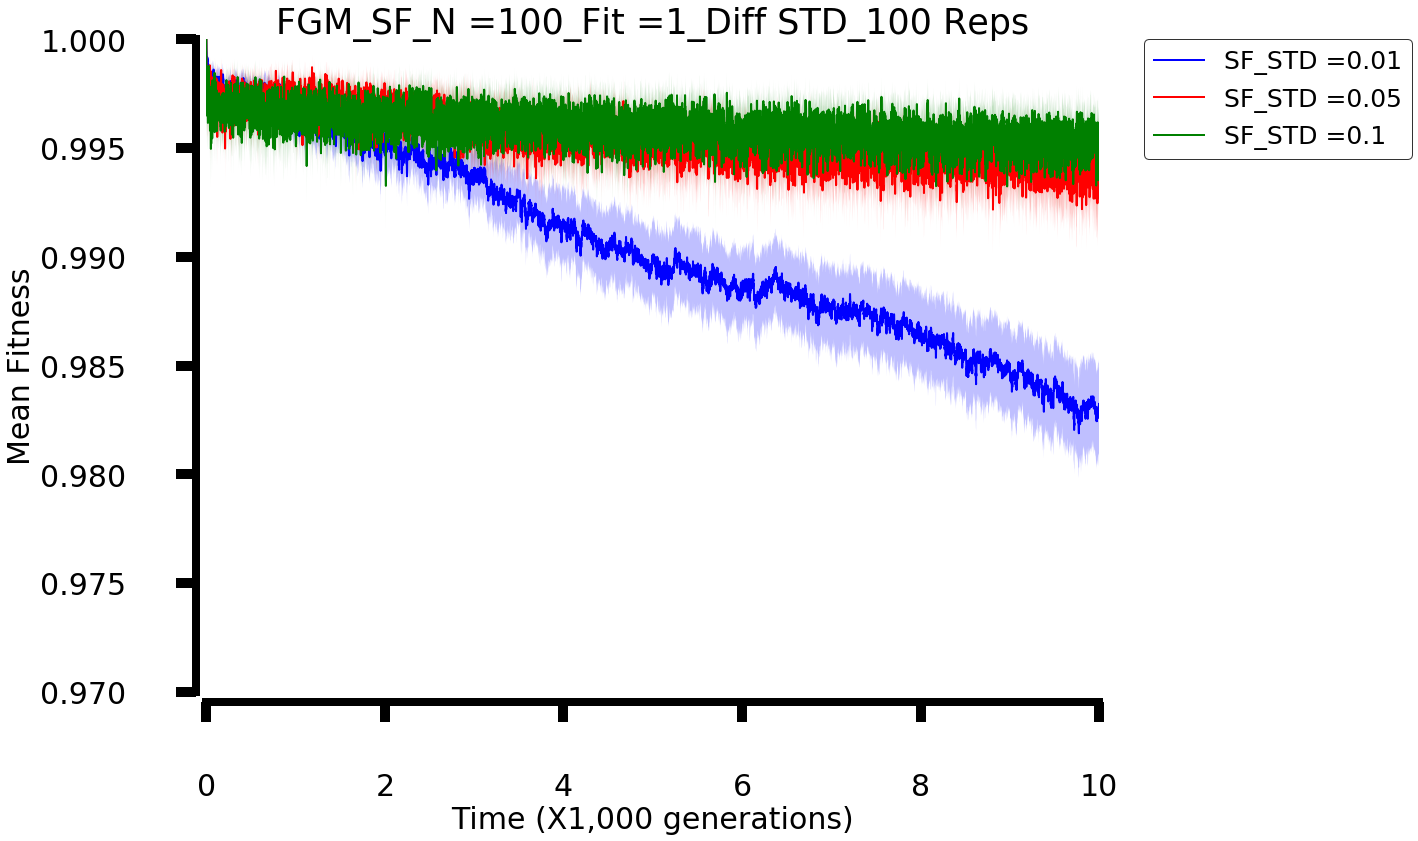

In [29]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[4]
error_a = list(1.96* np.array(sg01_fit_std[4])/((100)**0.5))

b = sg05_fit_mean[4]
error_b = list(1.96* np.array(sg05_fit_std[4])/((100)**0.5))

c = sg1_fit_mean[4]
error_c = list(1.96* np.array(sg1_fit_std[4])/((100)**0.5))


ax.set_title('FGM_SF_N =100_Fit =1_Diff STD_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'SF_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'SF_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'SF_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')


ax.set_ylim(9.7*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

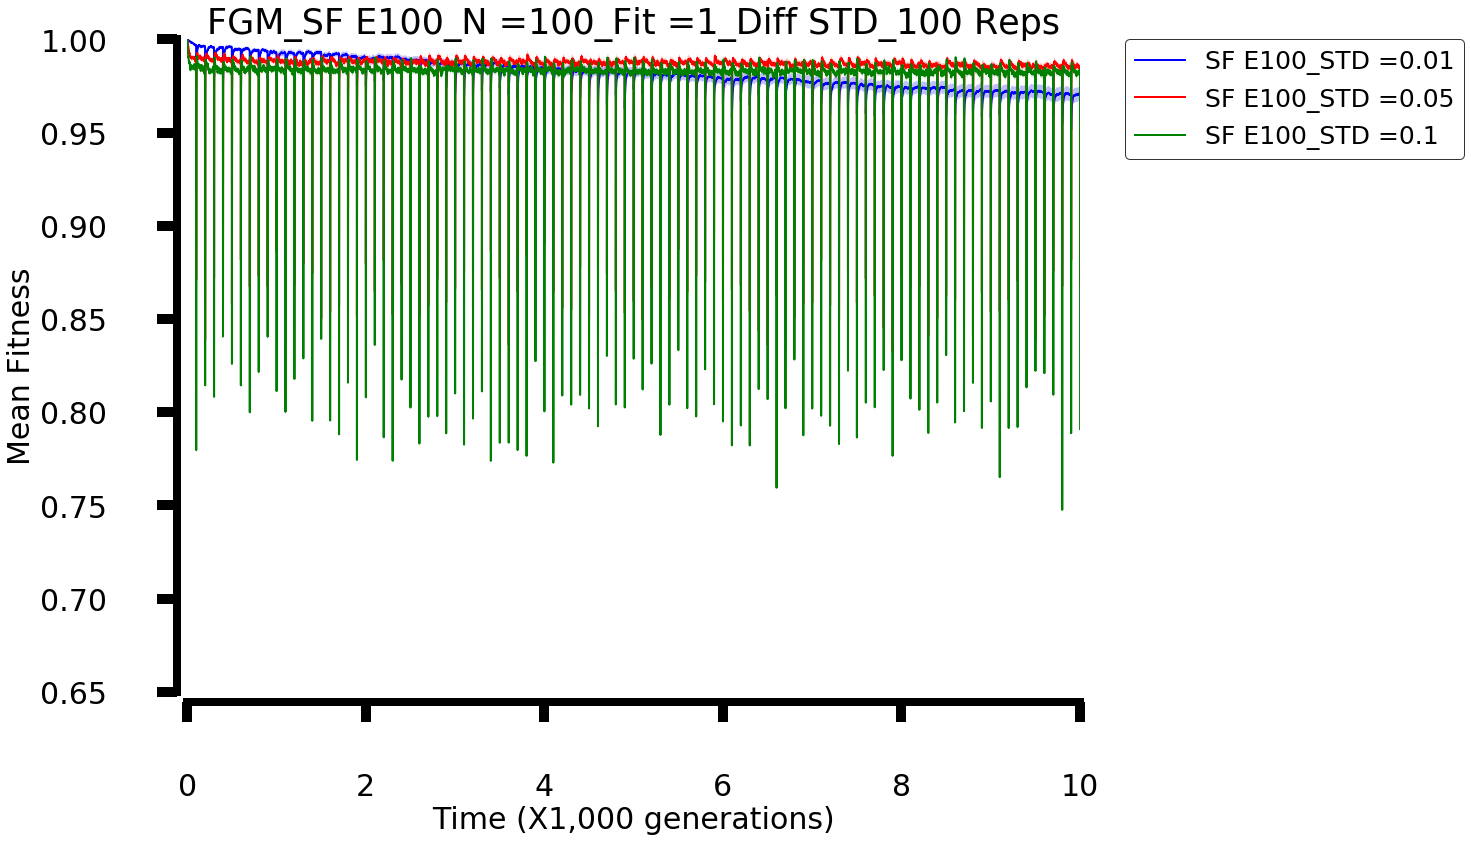

In [30]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = sg01_fit_mean[5]
error_a = list(1.96* np.array(sg01_fit_std[5])/((100)**0.5))

b = sg05_fit_mean[5]
error_b = list(1.96* np.array(sg05_fit_std[5])/((100)**0.5))

c = sg1_fit_mean[5]
error_c = list(1.96* np.array(sg1_fit_std[5])/((100)**0.5))


ax.set_title('FGM_SF E100_N =100_Fit =1_Diff STD_100 Reps', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'blue', label = 'SF E100_STD =0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.25, facecolor='blue')

ax.plot(t,b,'r', label = 'SF E100_STD =0.05', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='r')

ax.plot(t,c,'g', label = 'SF E100_STD =0.1', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.25, facecolor='g')





ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')



ax.set_ylim(6.5*10**(-1), 1)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))